Data Cleaning

The raw data for rtb_rent_raw is sourced from the Central Statistics Office, RIA02 – RTB Average Monthly Rent Report

In [195]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [196]:
df=pd.read_csv('dataset/rtb_rent_raw.csv')
df.head()

,STATISTIC,STATISTIC Label,TLIST(A1),Year,C02970V03592,Number of Bedrooms,C02969V03591,Property Type,C03004V03625,Location,UNIT,VALUE
0,RIA02,RTB Average Monthly Rent Report,2008,2008,-,All bedrooms,-,All property types,110000,Carlow,Euro,748.48
1,RIA02,RTB Average Monthly Rent Report,2008,2008,-,All bedrooms,-,All property types,110200,Carlow Town,Euro,811.53
2,RIA02,RTB Average Monthly Rent Report,2008,2008,-,All bedrooms,-,All property types,110300,"Graiguecullen, Carlow",Euro,711.35
3,RIA02,RTB Average Monthly Rent Report,2008,2008,-,All bedrooms,-,All property types,110500,"Tullow, Carlow",Euro,720.04
4,RIA02,RTB Average Monthly Rent Report,2008,2008,-,All bedrooms,-,All property types,110550,Cavan,Euro,571.72


Read the first ten rows of data to get a preliminary understanding of the variable structure and contents.

In [197]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 318444 entries, 0 to 318443
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   STATISTIC           318444 non-null  str    
 1   STATISTIC Label     318444 non-null  str    
 2   TLIST(A1)           318444 non-null  int64  
 3   Year                318444 non-null  int64  
 4   C02970V03592        318444 non-null  str    
 5   Number of Bedrooms  318444 non-null  str    
 6   C02969V03591        318444 non-null  str    
 7   Property Type       318444 non-null  str    
 8   C03004V03625        318444 non-null  int64  
 9   Location            318444 non-null  str    
 10  UNIT                318444 non-null  str    
 11  VALUE               109558 non-null  float64
dtypes: float64(1), int64(3), str(8)
memory usage: 29.2 MB


Year, Location, Number of Bedrooms, Property Type, and VALUE are useful columns containing a wealth of information.

The seven columns STATISTIC, STATISTIC Label, TLIST(A1), C02970V03592, C02969V03591, C03004V03625, and UNIT are format codes for the CSO database and have no practical value.

`VALUE` has only 109,558 non-null entries out of 318,444 rows (65.6% missing). Due to the highly specific filter criteria, there are no matching rental figures, resulting in a large number of missing values. However, this is to be expected.

In [198]:
dublin = df[df["Location"].str.contains("Dublin", case=False, na=False)].copy()
dublin = dublin[["Year", "Location", "Number of Bedrooms", "Property Type", "VALUE"]].copy()
dublin.columns = ["Year", "Location", "Bedrooms", "Property_type", "Rent"]
dublin.head(10)

,Year,Location,Bedrooms,Property_type,Rent
71,2008,Dublin,All bedrooms,All property types,1271.29
72,2008,"Balbriggan, Dublin",All bedrooms,All property types,1033.33
73,2008,"Blackrock, Dublin",All bedrooms,All property types,1587.10
74,2008,"Booterstown, Dublin",All bedrooms,All property types,1656.82
75,2008,"Cabinteely, Dublin",All bedrooms,All property types,NaN
76,2008,"Citywest, Dublin",All bedrooms,All property types,NaN
77,2008,"Dalkey, Dublin",All bedrooms,All property types,1655.47
78,2008,"Donabate, Dublin",All bedrooms,All property types,1146.57
79,2008,"Dun Laoghaire, Dublin",All bedrooms,All property types,1317.62
80,2008,"Glenageary, Dublin",All bedrooms,All property types,1711.18


As my project focuses solely on the Dublin area, I have filtered out the relevant information. I have also removed the database format codes mentioned above, retaining only the useful information. Finally, I have renamed the relevant rows and saved them as a new table.

In [199]:
dublin.isnull().sum()

Year                 0
Location             0
Bedrooms             0
Property_type        0
Rent             76693
dtype: int64

Missing data in the “Rent” section (record 76693), proceeding with missing value handling

In [200]:
df_new = dublin.dropna(subset=["Rent"]).copy()
df_new.isnull().sum()

Year             0
Location         0
Bedrooms         0
Property_type    0
Rent             0
dtype: int64

After removing the missing values from the ‘Rent’ column to complete the initial data cleaning, we can see that all columns now have zero missing values.

In [201]:
print(df_new["Property_type"].unique())
print(df_new["Bedrooms"].unique())
print(df_new["Year"].min(), "to", df_new["Year"].max())
print(df_new["Location"].nunique())

<StringArray>
[ 'All property types',      'Detached house', 'Semi detached house',
       'Terrace house',           'Apartment',         'Other flats']
Length: 6, dtype: str
<StringArray>
[ 'All bedrooms',       'One bed',       'Two bed',     'Three bed',
    '1 to 2 bed',    '1 to 3 bed', 'Four plus bed']
Length: 7, dtype: str
2008 to 2024
163


Examine the basic information in the table following the initial clean-up: room types, number of rooms, locations and dates. As there is a large amount of data regarding dates and locations, these are not displayed individually. There are no spelling mistakes or extra spaces, and the data is well-formatted.

In [202]:
agg_property = ["All property types"]

df_detail = df_new[
    (~df_new["Property_type"].isin(agg_property)) &
    (~df_new["Bedrooms"].isin(["All bedrooms", "1 to 2 bed", "1 to 3 bed"]))
].copy()

df_summary = df_new[
    (df_new["Property_type"] == "All property types") &
    (df_new["Bedrooms"] == "All bedrooms")
].copy()

print("Detail rows:", len(df_detail))
print("Summary rows:", len(df_summary))
print("\nDetail bedrooms:", df_detail["Bedrooms"].unique())


Detail rows: 10287
Summary rows: 2610

Detail bedrooms: <StringArray>
['One bed', 'Two bed', 'Three bed', 'Four plus bed']
Length: 4, dtype: str


As the data contains ‘All property types’ and ‘All bedrooms’, which affects the plotting, df_new has been split into two tables: df_detail and df_summary. df_detail is used specifically for plotting, whilst df_summary is retained as a backup for extracting general information.

As the ‘Bedrooms’ column overlaps with other data in the ‘1-2 bedrooms’ and ‘1-3 bedrooms’ categories, these two sections have been removed, leaving only ‘One bed’, ‘Two bed’, ‘Three bed’, ‘Four plus bed’ and ‘All bedrooms’.

In [203]:
df_mapping = pd.read_csv("dataset/location_to_district.csv")
df_detail = df_detail.merge(df_mapping, on="Location", how="left")

print("Mapping result:")
print(df_detail["District"].value_counts())
print("\nUnmapped locations:", df_detail["District"].isna().sum())
display(df_detail.head())

Mapping result:
District
D18    916
D6     815
D15    760
D4     742
D9     604
D3     600
D8     600
D1     472
D7     456
D24    403
D12    402
D14    398
D13    395
D16    389
D17    368
D6W    322
D11    320
D20    279
D2     237
D5     233
D10    119
Name: count, dtype: int64

Unmapped locations: 457


,Year,Location,Bedrooms,Property_type,Rent,District
0,2008,Dublin,One bed,Detached house,1031.97,NaN
1,2008,Dublin,One bed,Semi detached house,855.05,NaN
2,2008,Dublin 3,One bed,Semi detached house,745.08,D3
3,2008,Dublin 4,One bed,Semi detached house,911.54,D4
4,2008,Dublin 6,One bed,Semi detached house,801.92,D6


To facilitate subsequent dashboard analysis and charting, all locations in the table have been mapped to the administrative districts of Dublin 1–24.

After the mapping was successful, we checked for null values; there were 457 in total. The ‘location’ field was displayed as ‘Dublin’, which is too broad to be categorised.

In [204]:
df_detail = df_detail.dropna(subset=["District"])

The data relating to Dublin is too broad and of little practical use, so it has been removed.

In [205]:
df_detail["Rent"].describe()

count    9830.000000
mean     1437.481846
std       538.894034
min       488.130000
25%      1064.657500
50%      1331.465000
75%      1697.995000
max      6385.740000
Name: Rent, dtype: float64

Identifying outliers

The mean is 1,438. High-end properties have pushed up the average price, resulting in a right-skewed distribution, which is a normal distribution.

The maximum value is 6,385. This is not an outlier; the most expensive properties can indeed reach this price.

In [206]:
df_detail.to_csv("dataset/dublin_rent_detail.csv", index=False)
df_summary.to_csv("dataset/dublin_rent_summary.csv", index=False)

Export the two tables once the final clean-up is complete, the data cleaning phase is now complete.

EDA

1. Average rent in each district

In [207]:
rent_stats = df_detail.groupby("District")["Rent"].agg(["mean", "median"]).round(2)
rent_stats.columns = ["Mean Rent", "Median Rent"]
rent_stats = rent_stats.sort_values("Median Rent", ascending=False)
print(rent_stats)

          Mean Rent  Median Rent
District                        
D4          1875.30      1763.08
D14         1651.58      1582.66
D2          1592.43      1555.67
D18         1670.59      1541.47
D16         1603.38      1525.78
D6          1536.60      1444.71
D6W         1473.74      1406.30
D17         1455.10      1329.80
D3          1371.63      1304.00
D13         1373.99      1289.17
D9          1330.71      1283.30
D8          1283.16      1247.13
D5          1326.72      1241.38
D12         1253.24      1212.30
D20         1286.06      1203.55
D15         1265.88      1200.66
D1          1363.02      1197.10
D24         1260.91      1191.24
D7          1221.13      1174.37
D11         1178.34      1128.37
D10         1087.03      1014.06


The information above shows the average and median rents for various areas of Dublin. As the average is skewed to the right due to a few particularly expensive properties, the median has been included. D4 has the highest average rent, and the difference between the median and average is greatest in D4, D18 and D1. These areas have the highest concentration of expensive properties, which has pushed up the average.

2. Number of properties available in each district

In [208]:
listing_count = df_detail.groupby("District").size().sort_values(ascending=False)
print(listing_count)

District
D18    916
D6     815
D15    760
D4     742
D9     604
D8     600
D3     600
D1     472
D7     456
D24    403
D12    402
D14    398
D13    395
D16    389
D17    368
D6W    322
D11    320
D20    279
D2     237
D5     233
D10    119
dtype: int64


There is a large number of properties available in areas such as D18, D6, D15 and D4, whilst area D2 has fewer properties but higher average rents, indicating that rents are highly concentrated in the high-end market.

3. Median rent for different property types and numbers of bedrooms

In [209]:
avg_by_property = df_detail.groupby("Property_type")["Rent"].median().sort_values(ascending=False).round(2)
print("Median Rent by Property Type:")
print(avg_by_property)

avg_by_bedrooms = df_detail.groupby("Bedrooms")["Rent"].median().sort_values(ascending=False).round(2)
print("\nMedian Rent by Bedrooms:")
print(avg_by_bedrooms)

Median Rent by Property Type:
Property_type
Detached house         2084.76
Semi detached house    1461.50
Terrace house          1373.03
Apartment              1308.12
Other flats             877.47
Name: Rent, dtype: float64

Median Rent by Bedrooms:
Bedrooms
Four plus bed    1911.35
Three bed        1462.57
Two bed          1279.17
One bed           997.52
Name: Rent, dtype: float64


The type of property and the number of bedrooms have a significant impact on rent, so the average rent figures in the first section of the EDA are too general.
Detached houses have the highest median rent (€2,084), which is almost 2.4 times that of ‘Other flats’ (€877). Flats are the most common type of rental property in Dublin, with a median rent of €1,308. The number of bedrooms is a key predictor of rent: for every additional bedroom, the monthly rent increases by approximately €300 to €450, and properties with four or more bedrooms (€1,911) command almost double the rent of one-bedroom flats (€998). These findings confirm that, in order to make meaningful comparisons, property type and number of bedrooms must be included as filter criteria in the dashboard.

4. Rental growth rates by district (by year)

In [210]:
rent_trend = df_detail.groupby(["Year", "District"])["Rent"].median().reset_index()
rent_2008 = rent_trend[rent_trend["Year"] == 2008].set_index("District")["Rent"]
rent_2024 = rent_trend[rent_trend["Year"] == 2024].set_index("District")["Rent"]
growth = ((rent_2024 - rent_2008) / rent_2008 * 100).dropna().sort_values(ascending=False).round(1)
print(growth)

District
D20    78.2
D5     57.8
D16    56.5
D11    56.2
D24    55.8
D17    55.8
D8     55.6
D1     54.4
D15    54.4
D18    54.4
D7     51.9
D13    50.5
D9     49.0
D10    48.6
D12    45.0
D4     41.4
D3     40.5
D14    38.6
D6     34.7
D6W    31.6
D2     20.0
Name: Rent, dtype: float64


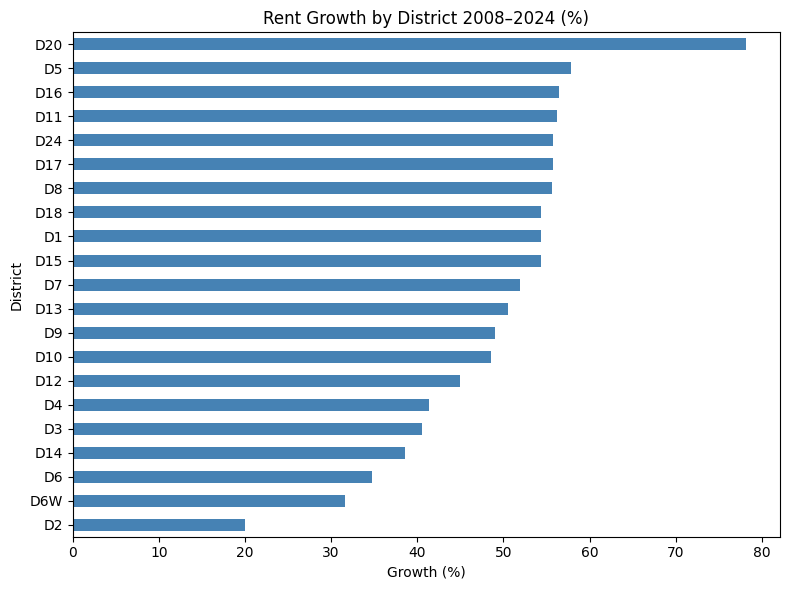

In [211]:
import matplotlib.pyplot as plt

growth.sort_values().plot(kind="barh", figsize=(8, 6), color="steelblue")
plt.title("Rent Growth by District 2008–2024 (%)")
plt.xlabel("Growth (%)")
plt.tight_layout()
plt.show()

The most significant increase was observed in D20 (78.2%), followed by D5 and D16. In contrast, areas traditionally characterised by higher rents, such as D2 and D4, saw only modest increases. Peripheral areas and those with historically lower rents experienced more substantial rises. This finding prompted the addition of a year range slider to the dashboard, enabling users to explore rental trends across different time periods.